In [26]:
import numpy as np
import torch
import torch.nn as nn
import sys

In [27]:
sys.path.append('../data_exploration')
from wikidata_dataset_class import GlobalTemporalTextKGDataset

# dummy args — not used since the dataset is already processed on disk
dataset = GlobalTemporalTextKGDataset(
    start_year=0,
    json_filename="",
    dataset_filename="descriptions_dataset_1800.pt",
    root="../data_exploration/data/wikidata",
    entity_to_id={},
    relation_to_id={},
    entity_to_data={},
    embed_fn=lambda x: None
)
print(f"dataset len: {len(dataset)}")
print(f"x_global:    {dataset.x_global.shape}")
print(f"num_rels:    {len(dataset.id_to_rel)}")


dataset len: 220
x_global:    torch.Size([10834, 768])
num_rels:    23


In [28]:
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax


class MultiHeadTemporalGAT(MessagePassing):
    def __init__(self, node_dim, edge_emb_dim, num_edge_types, heads=4, dropout=0.1):
        super().__init__(aggr="add")

        # make sure sizing is right
        assert node_dim % heads == 0, "node_dim must be divisible by heads"

        # attributes
        # NOTE: named out_dim to avoid stomping MessagePassing.node_dim
        self.out_dim = node_dim
        self.heads = heads
        self.head_dim = node_dim // heads
        self.dropout = dropout

        # edge embeddings
        self.edge_embedding = nn.Embedding(num_edge_types, edge_emb_dim)

        # projections
        self.W_h = nn.Linear(node_dim, node_dim, bias=False) # for node embeddings in message
        self.W_r = nn.Linear(edge_emb_dim, node_dim, bias=False) # for edge embeddings in message
        self.W_n = nn.Linear(node_dim, node_dim, bias=False) # for node embeddings in attention

        # attention MLP operates per head
        # shared accross all heads (not as good as full multihead, but much cheaper)
        # expects concat of both node embeddings and the edge embedding
        # outputs a scalar, the attention score
        self.att_mlp = nn.Sequential(
            nn.Linear(2 * self.head_dim + edge_emb_dim, self.head_dim),
            nn.LeakyReLU(),
            nn.Linear(self.head_dim, 1)
        )

        # output and normalization
        self.out_proj = nn.Linear(node_dim, node_dim)
        self.norm = nn.LayerNorm(node_dim)

    def forward(self, x, edge_index, edge_type):
        # dims
        # x is (num_nodes, node_dim)
        # edge_index is (2, num_edges)
        # edge_type is (num_edges)

        # get edge embeddings (num_edges, edge_emb_dim)
        edge_attr = self.edge_embedding(edge_type)

        # propagates messages
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        # serves to mix info from different heads
        out = self.out_proj(out)

        # residual and norm
        return self.norm(x + out)

    # message is called in propagate
    def message(self, x_i, x_j, edge_attr, index):
        # apply transfomation to node embeddings
        z_i = self.W_n(x_i) # (num_edges, node_dim)
        z_j = self.W_n(x_j)

        # apply message transfomation to node embedding
        m_j = self.W_h(x_j) # (num_edges, node_dim)

        # apply message transformation to edge embedding and project to node space
        e_j = self.W_r(edge_attr) # (num_edges, node_dim)

        # reshape (num_edges, heads, head_dim) for multihead attention
        z_i = z_i.view(-1, self.heads, self.head_dim)
        z_j = z_j.view(-1, self.heads, self.head_dim)
        m_j = m_j.view(-1, self.heads, self.head_dim)
        e_j = e_j.view(-1, self.heads, self.head_dim)

        # expand edge_attr to heads (num_edges, num_heads, edge_emb_dim)
        # for attention
        edge_attr = edge_attr.unsqueeze(1).repeat(1, self.heads, 1)

        # attention per head
        att_input = torch.cat([z_i, z_j, edge_attr], dim=-1) # (num_edges, num_heads, (2 * head_dim + edge_emb_dim))
        e_ij = self.att_mlp(att_input).squeeze(-1)   # (num_edges, heads)

        # apply softmax to attention scores to get attention weights
        alpha = softmax(e_ij, index)                 # normalize per node
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)

        # calculate messages
        msg = m_j + e_j     # (num_edges, num_heads, head_dim)

        # weight messages and return
        return alpha.unsqueeze(-1) * msg   # (num_edges, heads, head_dim)

    def aggregate(self, inputs, index, ptr=None, dim_size=None):
        # inputs: (num_edges, heads, head_dim) -> flatten heads before scatter
        inputs_flat = inputs.view(inputs.size(0), -1)   # (num_edges, out_dim)
        return super().aggregate(inputs_flat, index, ptr, dim_size)  # (num_nodes, out_dim)


In [29]:
class NodeLSTM(nn.Module):
    """
    Per-node temporal memory module.

    Input:
        x_t: current node representations at time t
             shape [num_nodes, input_dim]

        state: optional tuple (h_prev, c_prev)
             h_prev: [num_nodes, hidden_dim]
             c_prev: [num_nodes, hidden_dim]

    Output:
        h_t: updated node hidden states
             shape [num_nodes, hidden_dim]

        (h_t, c_t): updated recurrent state
    """

    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.cell = nn.LSTMCell(input_dim, hidden_dim)

    def init_state(self, num_nodes, device):
        h0 = torch.zeros(num_nodes, self.hidden_dim, device=device)
        c0 = torch.zeros(num_nodes, self.hidden_dim, device=device)
        return h0, c0

    def forward(self, x_t, state=None):
        """
        x_t: [num_nodes, input_dim]
        state: (h_prev, c_prev) or None
        """
        num_nodes = x_t.size(0)
        device = x_t.device

        if state is None:
            h_prev, c_prev = self.init_state(num_nodes, device)
        else:
            h_prev, c_prev = state

        # LSTMCell treats num_nodes like the batch dimension,
        # so each node gets its own temporal update.
        h_t, c_t = self.cell(x_t, (h_prev, c_prev))

        return h_t, (h_t, c_t)

In [30]:
from collections import defaultdict
import itertools


class TripleProposalStrategy:
    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states, metadata=None):
        raise NotImplementedError


class CurrentEdgeSetStrategy(TripleProposalStrategy):
    """Passes every edge in the current graph as a candidate.
    Combined with other strategies this lets the model regenerate
    the entire graph at each timestep (including deletions)."""

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states, metadata=None):
        src = edge_index[0].tolist()
        dst = edge_index[1].tolist()
        rel = edge_type.tolist()
        return list(zip(src, rel, dst))


class AllTripletStrategy(TripleProposalStrategy):
    """Proposes every possible (src, rel, dst) triple over active nodes.
    Active nodes are those present in the current edge_index.
    Self-loops are excluded.

    Warning: scales as O(|active_nodes|^2 * |relations|).
    Keep active node counts modest or use max_candidates in TripleProposer."""

    def __init__(self, allowed_relations):
        self.allowed_relations = allowed_relations

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states, metadata=None):
        active = edge_index.unique().tolist()
        proposals = [
            (u, r, v)
            for u, v in itertools.permutations(active, 2)
            for r in self.allowed_relations
        ]
        return proposals


class TwoHopExpansionStrategy(TripleProposalStrategy):
    def __init__(self, allowed_relations, max_per_node=20):
        self.allowed_relations = allowed_relations
        self.max_per_node = max_per_node

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states, metadata=None):
        num_nodes = graph_node_states.size(0)
        out_neighbors = defaultdict(set)
        for s, d in zip(edge_index[0].tolist(), edge_index[1].tolist()):
            out_neighbors[s].add(d)
        proposals = []
        for u in range(num_nodes):
            count = 0
            for mid in out_neighbors[u]:
                for v in out_neighbors[mid]:
                    if u == v:
                        continue
                    for r in self.allowed_relations:
                        proposals.append((u, r, v))
                    count += 1
                    if count >= self.max_per_node:
                        break
                if count >= self.max_per_node:
                    break
        return proposals


class SimilarStateStrategy(TripleProposalStrategy):
    def __init__(self, allowed_relations, topk=10):
        self.allowed_relations = allowed_relations
        self.topk = topk

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states, metadata=None):
        # only run over active nodes to avoid O(num_nodes^2) on large graphs
        active = edge_index.unique()
        x = lstm_node_states[active]
        x_norm = x / (x.norm(dim=-1, keepdim=True) + 1e-8)
        sim = x_norm @ x_norm.T
        active_list = active.tolist()
        proposals = []
        for i, u in enumerate(active_list):
            k = min(self.topk + 1, sim.size(1))
            _, indices = torch.topk(sim[i], k=k)
            for j in indices.tolist():
                v = active_list[j]
                if u == v:
                    continue
                for r in self.allowed_relations:
                    proposals.append((u, r, v))
        return proposals


class TripleProposer(nn.Module):
    def __init__(self, strategies, max_candidates=None):
        super().__init__()
        self.strategies = strategies
        self.max_candidates = max_candidates

    def forward(self, edge_index, edge_type, graph_node_states, lstm_node_states, metadata=None):
        proposals = []
        for strategy in self.strategies:
            proposals.extend(strategy.propose(
                edge_index=edge_index, edge_type=edge_type,
                graph_node_states=graph_node_states, lstm_node_states=lstm_node_states,
                metadata=metadata,
            ))
        proposals = list(set(proposals))
        if len(proposals) == 0:
            return torch.empty((0, 3), dtype=torch.long, device=graph_node_states.device)
        if self.max_candidates is not None:
            proposals = proposals[:self.max_candidates]
        return torch.tensor(proposals, dtype=torch.long, device=graph_node_states.device)


In [31]:
class TripleScorer(nn.Module):
    """
    Scores proposed triples (src, rel, dst), conditioned on both:
      1. current node representation from the graph encoder
      2. per-node LSTM hidden state

    Inputs
    ------
    graph_node_states : Tensor [num_nodes, graph_dim]
        Structural node representations from the GNN / graph transformer.
    lstm_node_states : Tensor [num_nodes, lstm_dim]
        Per-node LSTM hidden states.
    proposed_triples : LongTensor [num_triples, 3]
        Each row is (src_node_id, rel_id, dst_node_id)

    Output
    ------
    logits : Tensor [num_triples]
        Raw scores for each proposed triple.
        Use BCEWithLogitsLoss on these logits outside the class.
    """

    def __init__(self, graph_dim, lstm_dim, num_relations, hidden_dim, rel_dim):
        super().__init__()

        self.graph_dim = graph_dim
        self.lstm_dim = lstm_dim
        self.node_dim = graph_dim + lstm_dim
        self.rel_dim = rel_dim if rel_dim is not None else self.node_dim

        self.rel_emb = nn.Embedding(num_relations, self.rel_dim)

        # Small MLP scorer over:
        # [src_graph, src_lstm, rel, dst_graph, dst_lstm]
        self.mlp = nn.Sequential(
            nn.Linear(self.node_dim + self.rel_dim + self.node_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, graph_node_states, lstm_node_states, proposed_triples):
        if proposed_triples.dtype != torch.long:
            proposed_triples = proposed_triples.long()

        src = proposed_triples[:, 0]   # [num_triples]
        rel = proposed_triples[:, 1]   # [num_triples]
        dst = proposed_triples[:, 2]   # [num_triples]

        # Gather graph-conditioned node states
        src_graph = graph_node_states[src]   # [num_triples, graph_dim]
        dst_graph = graph_node_states[dst]   # [num_triples, graph_dim]

        # Gather temporal LSTM node states
        src_lstm = lstm_node_states[src]     # [num_triples, lstm_dim]
        dst_lstm = lstm_node_states[dst]     # [num_triples, lstm_dim]

        # Combine graph + temporal information per endpoint
        src_state = torch.cat([src_graph, src_lstm], dim=-1)   # [num_triples, node_dim]
        dst_state = torch.cat([dst_graph, dst_lstm], dim=-1)   # [num_triples, node_dim]

        # Relation embedding
        rel_state = self.rel_emb(rel)                         # [num_triples, rel_dim]

        # Final triple representation
        triple_repr = torch.cat([src_state, rel_state, dst_state], dim=-1)

        # Raw logits
        logits = self.mlp(triple_repr).squeeze(-1)            # [num_triples]
        return logits

In [32]:
def proposed_triple_bce_loss(
    proposed_triples: torch.Tensor,
    logits: torch.Tensor,
    next_edge_index: torch.Tensor,
    next_edge_type: torch.Tensor,
    pos_weight: torch.Tensor | None = None,
    reduction: str = "mean",
):
    """
    BCE loss over a proposed candidate set.

    Assumes proposed_triples already contains the full candidate set you want
    to train on, e.g.
      - all current edges
      - all other strategy proposals
      - optionally other forced candidates

    Any proposed triple that is present in the next graph gets label 1.
    All other proposed triples get label 0.

    Parameters
    ----------
    proposed_triples : LongTensor [num_candidates, 3]
        Candidate triples (src, rel, dst).

    logits : Tensor [num_candidates]
        Raw scorer outputs for each candidate triple.

    next_edge_index : LongTensor [2, num_true_next_edges]
        Ground-truth next graph edges.

    next_edge_type : LongTensor [num_true_next_edges]
        Ground-truth next graph relation ids.

    pos_weight : Tensor | None
        Optional positive weight for BCEWithLogitsLoss.

    reduction : str
        Reduction passed to BCEWithLogitsLoss, usually "mean" or "sum".

    Returns
    -------
    loss : Tensor
        Scalar loss.

    labels : Tensor [num_candidates]
        Binary labels for each proposed triple.

    positives_mask : BoolTensor [num_candidates]
        True where proposed triple exists in next graph.
    """
    device = proposed_triples.device

    if proposed_triples.ndim != 2 or proposed_triples.size(1) != 3:
        raise ValueError("proposed_triples must have shape [num_candidates, 3]")

    if logits.ndim != 1 or logits.size(0) != proposed_triples.size(0):
        raise ValueError("logits must have shape [num_candidates]")

    # Build set of true triples from next graph
    next_src = next_edge_index[0]
    next_dst = next_edge_index[1]
    next_rel = next_edge_type

    true_next_triples = torch.stack([next_src, next_rel, next_dst], dim=1).long()

    true_next_set = set(map(tuple, true_next_triples.tolist()))

    # Label each proposed triple by membership in next graph
    labels_list = [
        1.0 if tuple(triple) in true_next_set else 0.0
        for triple in proposed_triples.tolist()
    ]

    labels = torch.tensor(labels_list, dtype=logits.dtype, device=device)
    positives_mask = labels.bool()

    loss = F.binary_cross_entropy_with_logits(
        logits,
        labels,
        pos_weight=pos_weight,
        reduction=reduction,
    )

    return loss, labels, positives_mask

In [33]:
import os
import networkx as nx
import matplotlib.pyplot as plt

class Temporal_GNN(nn.Module):
    def __init__(
        self,
        in_dim,
        hidden_dim,
        edge_emb_dim,
        num_edge_types,
        num_gnn_layers=2,
        heads=4,
        dropout=0.1,
        max_candidates=None,
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_edge_types = num_edge_types

        # project pretrained semantic embeddings into hidden_dim
        self.init_embedding = nn.Linear(in_dim, hidden_dim)

        # stack of GNN layers
        self.gnn_layers = nn.ModuleList([
            MultiHeadTemporalGAT(hidden_dim, edge_emb_dim, num_edge_types, heads=heads, dropout=dropout)
            for _ in range(num_gnn_layers)
        ])

        # per-node temporal memory
        self.node_lstm = NodeLSTM(hidden_dim, hidden_dim)

        # candidate proposer: current edges + 2-hop structural + embedding similarity
        all_rels = list(range(num_edge_types))
        self.proposer = TripleProposer(
            strategies=[
                CurrentEdgeSetStrategy(),
                TwoHopExpansionStrategy(allowed_relations=all_rels, max_per_node=20),
                SimilarStateStrategy(allowed_relations=all_rels, topk=10),
            ],
            max_candidates=max_candidates,
        )

        # triple scorer conditioned on both graph and lstm states
        self.scorer = TripleScorer(
            graph_dim=hidden_dim,
            lstm_dim=hidden_dim,
            num_relations=num_edge_types,
            hidden_dim=hidden_dim,
            rel_dim=edge_emb_dim,
        )

    def forward(self, x_global, edge_index, edge_type, lstm_state=None):
        # x_global:   [num_nodes, in_dim]
        # edge_index: [2, num_edges]
        # edge_type:  [num_edges]
        # lstm_state: (h, c) each [num_nodes, hidden_dim] or None

        # project to hidden dim
        x = self.init_embedding(x_global)       # [num_nodes, hidden_dim]

        # GNN layers
        for gnn in self.gnn_layers:
            x = gnn(x, edge_index, edge_type)

        graph_node_states = x                   # [num_nodes, hidden_dim]

        # update per-node LSTM
        lstm_h, lstm_state = self.node_lstm(graph_node_states, lstm_state)

        # propose candidates using current edges + structural + similarity strategies
        proposed_triples = self.proposer(
            edge_index=edge_index,
            edge_type=edge_type,
            graph_node_states=graph_node_states,
            lstm_node_states=lstm_h,
        )                                       # [num_candidates, 3]

        # score candidates
        logits = self.scorer(graph_node_states, lstm_h, proposed_triples)

        return logits, proposed_triples, lstm_state

    @torch.no_grad()
    def gen(self, x_global, edge_index, edge_type, id_to_entity, id_to_rel,
            num_steps=5, topk=20, threshold=0.5, device='cpu', save_dir=None):
        self.eval()
        x_global   = x_global.to(device)
        edge_index = edge_index.to(device)
        edge_type  = edge_type.to(device)
        lstm_state = None

        for step in range(num_steps):
            logits, proposed_triples, lstm_state = self.forward(
                x_global, edge_index, edge_type, lstm_state
            )

            if proposed_triples.size(0) == 0:
                print(f"step {step + 1}: no candidates proposed, stopping.")
                break

            probs = torch.sigmoid(logits)

            above = (probs > threshold).nonzero(as_tuple=True)[0]
            if above.numel() == 0:
                above = torch.arange(probs.size(0), device=device)
            k = min(topk, above.size(0))
            _, best = torch.topk(probs[above], k)
            selected = proposed_triples[above[best]]  # [k, 3]

            edge_index = torch.stack([selected[:, 0], selected[:, 2]], dim=0)
            edge_type  = selected[:, 1]

            # build networkx directed graph
            G = nx.DiGraph()
            for src_id, rel_id, dst_id in selected.cpu().tolist():
                src_lbl = id_to_entity.get(src_id, str(src_id))
                dst_lbl = id_to_entity.get(dst_id, str(dst_id))
                rel_lbl = id_to_rel.get(rel_id, str(rel_id))
                G.add_edge(src_lbl, dst_lbl, relation=rel_lbl)

            fig, ax = plt.subplots(figsize=(14, 10))
            pos = nx.spring_layout(G, seed=42)

            nx.draw_networkx_nodes(G, pos, node_size=400, ax=ax)
            nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)

            # draw directed edges with visible arrowheads
            nx.draw_networkx_edges(
                G, pos,
                ax=ax,
                arrows=True,
                arrowstyle='-|>',
                arrowsize=20,
                connectionstyle='arc3,rad=0.1',
                min_source_margin=15,
                min_target_margin=15,
            )

            nx.draw_networkx_edge_labels(
                G, pos,
                edge_labels=nx.get_edge_attributes(G, 'relation'),
                font_size=6, ax=ax,
            )
            ax.set_title(
                f"Generated graph — step {step + 1}  "
                f"({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)"
            )
            ax.axis('off')
            plt.tight_layout()

            if save_dir:
                os.makedirs(save_dir, exist_ok=True)
                out_path = os.path.join(save_dir, f"step_{step + 1:03d}.png")
                plt.savefig(out_path, dpi=100)
                plt.close()
                print(f"step {step + 1}: {G.number_of_nodes()} nodes, "
                      f"{G.number_of_edges()} edges  ->  {out_path}")
            else:
                plt.show()
                print(f"step {step + 1}: {G.number_of_nodes()} nodes, "
                      f"{G.number_of_edges()} edges")

        return edge_index, edge_type


In [34]:
VAL_STEPS = 10

def train_epoch(model, dataset, optimizer, device, train_end):
    model.train()
    total_loss, steps = 0.0, 0
    x_global   = dataset.x_global.to(device)
    lstm_state = None

    for t in range(train_end - 1):
        data_t    = dataset[t]
        data_next = dataset[t + 1]
        edge_index = data_t.edge_index.to(device)
        edge_type  = data_t.edge_type.to(device)

        logits, proposed_triples, lstm_state = model(x_global, edge_index, edge_type, lstm_state)
        lstm_state = (lstm_state[0].detach(), lstm_state[1].detach())

        if proposed_triples.size(0) == 0:
            continue

        loss, _, _ = proposed_triple_bce_loss(
            proposed_triples, logits,
            data_next.edge_index.to(device), data_next.edge_type.to(device),
        )
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        steps += 1

    return total_loss / max(steps, 1)


@torch.no_grad()
def validate(model, dataset, device, val_start):
    model.eval()
    total_loss  = 0.0
    total_hits1 = 0.0
    total_hits3 = 0.0
    total_hits10 = 0.0
    total_pos   = 0
    steps       = 0
    x_global    = dataset.x_global.to(device)
    lstm_state  = None

    # warm up lstm on the last few training steps so state isn't cold
    for t in range(max(0, val_start - 5), val_start):
        data_t = dataset[t]
        _, _, lstm_state = model(
            x_global,
            data_t.edge_index.to(device),
            data_t.edge_type.to(device),
            lstm_state,
        )
        lstm_state = (lstm_state[0].detach(), lstm_state[1].detach())

    for t in range(val_start, len(dataset) - 1):
        data_t    = dataset[t]
        data_next = dataset[t + 1]
        edge_index = data_t.edge_index.to(device)
        edge_type  = data_t.edge_type.to(device)

        logits, proposed_triples, lstm_state = model(x_global, edge_index, edge_type, lstm_state)
        lstm_state = (lstm_state[0].detach(), lstm_state[1].detach())

        if proposed_triples.size(0) == 0:
            continue

        loss, labels, pos_mask = proposed_triple_bce_loss(
            proposed_triples, logits,
            data_next.edge_index.to(device), data_next.edge_type.to(device),
        )
        total_loss += loss.item()

        # hits@k: for each positive triple, check if it ranks in top k by score
        num_pos = pos_mask.sum().item()
        if num_pos > 0:
            scores = logits  # higher = more likely
            pos_scores = scores[pos_mask]  # [num_pos]
            # rank of each positive = number of candidates scored higher
            ranks = (scores.unsqueeze(0) > pos_scores.unsqueeze(1)).sum(dim=1) + 1  # [num_pos]
            total_hits1  += (ranks <= 1).float().sum().item()
            total_hits3  += (ranks <= 3).float().sum().item()
            total_hits10 += (ranks <= 10).float().sum().item()
            total_pos    += num_pos

        steps += 1

    n = max(total_pos, 1)
    return {
        "loss":    total_loss / max(steps, 1),
        "hits@1":  total_hits1  / n,
        "hits@3":  total_hits3  / n,
        "hits@10": total_hits10 / n,
    }


# ---- hyperparams ----
HIDDEN_DIM     = 256
EDGE_EMB_DIM   = 64
NUM_GNN_LAYERS = 2
HEADS          = 4
DROPOUT        = 0.1
LR             = 1e-3
EPOCHS         = 10
MAX_CANDS      = 500

device         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IN_DIM         = dataset.x_global.shape[1]        # derived from dataset (768)
NUM_EDGE_TYPES = len(dataset.id_to_rel)            # derived from dataset (23)
TRAIN_END      = len(dataset) - VAL_STEPS          # last VAL_STEPS held out for validation
print(f"device: {device}  IN_DIM: {IN_DIM}  NUM_EDGE_TYPES: {NUM_EDGE_TYPES}")
print(f"train timesteps: 0–{TRAIN_END - 1}  |  val timesteps: {TRAIN_END}–{len(dataset) - 1}")

model = Temporal_GNN(
    in_dim=IN_DIM,
    hidden_dim=HIDDEN_DIM,
    edge_emb_dim=EDGE_EMB_DIM,
    num_edge_types=NUM_EDGE_TYPES,
    num_gnn_layers=NUM_GNN_LAYERS,
    heads=HEADS,
    dropout=DROPOUT,
    max_candidates=None,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, dataset, optimizer, device, train_end=TRAIN_END)
    val_metrics = validate(model, dataset, device, val_start=TRAIN_END)
    print(
        f"epoch {epoch:3d} | "
        f"train loss {train_loss:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | "
        f"hits@1 {val_metrics['hits@1']:.3f}  "
        f"hits@3 {val_metrics['hits@3']:.3f}  "
        f"hits@10 {val_metrics['hits@10']:.3f}"
    )


device: cuda  IN_DIM: 768  NUM_EDGE_TYPES: 23
train timesteps: 0–209  |  val timesteps: 210–219
epoch   1 | train loss 0.0092 | val loss 0.0713 | hits@1 0.001  hits@3 0.003  hits@10 0.011
epoch   2 | train loss 0.0010 | val loss 0.0897 | hits@1 0.001  hits@3 0.003  hits@10 0.011
epoch   3 | train loss 0.0008 | val loss 0.0888 | hits@1 0.001  hits@3 0.003  hits@10 0.011
epoch   4 | train loss 0.0008 | val loss 0.0895 | hits@1 0.001  hits@3 0.003  hits@10 0.010
epoch   5 | train loss 0.0008 | val loss 0.1207 | hits@1 0.001  hits@3 0.003  hits@10 0.010
epoch   6 | train loss 0.0007 | val loss 0.1130 | hits@1 0.001  hits@3 0.003  hits@10 0.010
epoch   7 | train loss 0.0007 | val loss 0.0987 | hits@1 0.001  hits@3 0.003  hits@10 0.011
epoch   8 | train loss 0.0007 | val loss 0.1101 | hits@1 0.001  hits@3 0.003  hits@10 0.010
epoch   9 | train loss 0.0007 | val loss 0.1060 | hits@1 0.001  hits@3 0.003  hits@10 0.010
epoch  10 | train loss 0.0007 | val loss 0.1080 | hits@1 0.001  hits@3 0.003

subgraph: 30 nodes, 30 edges


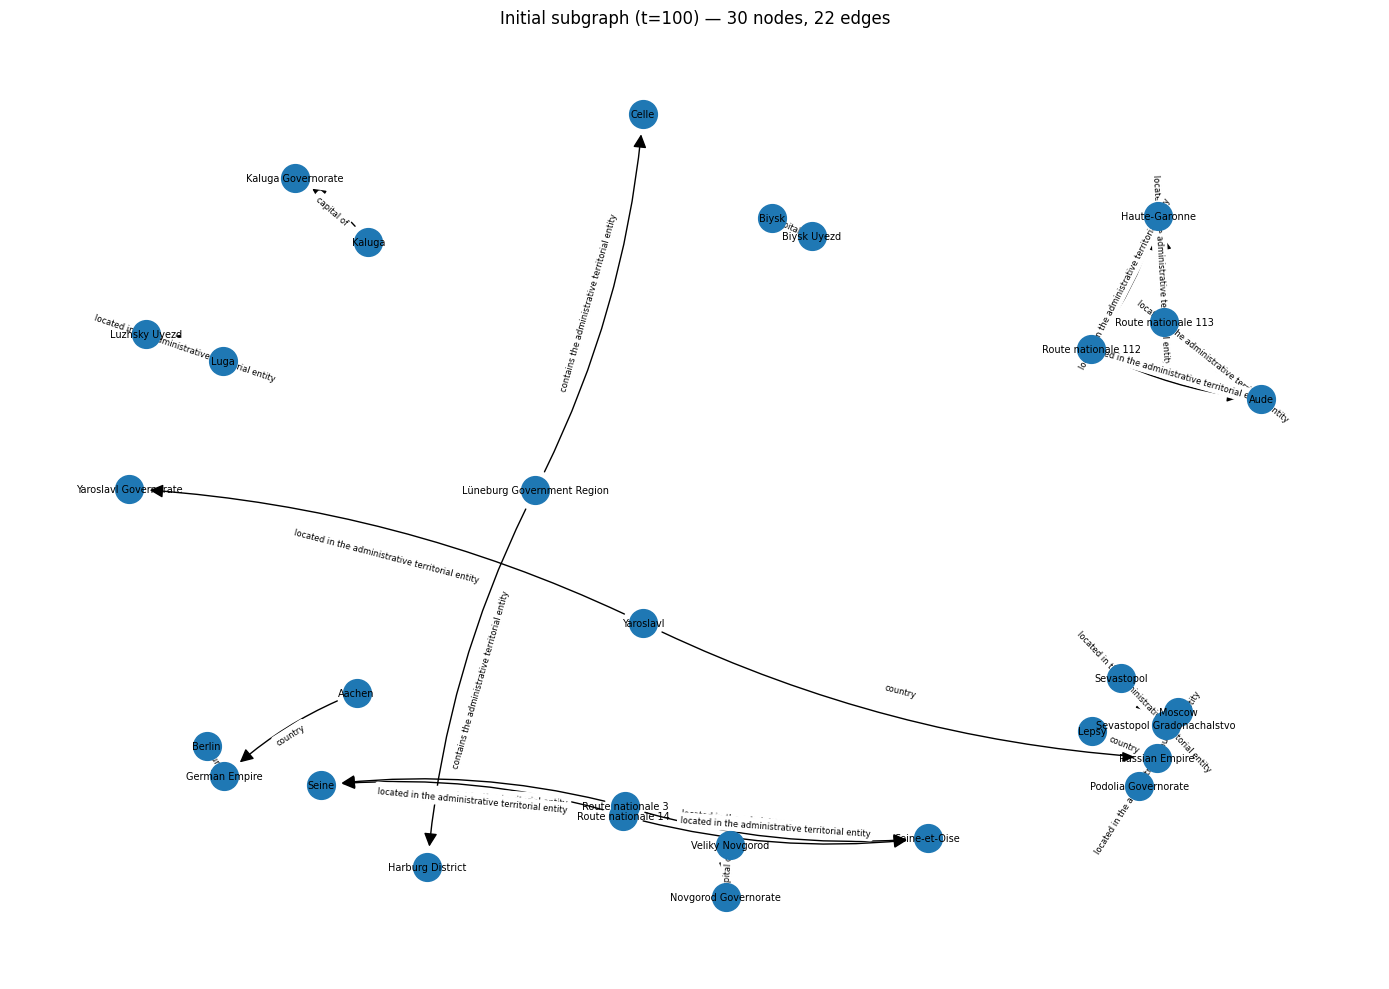

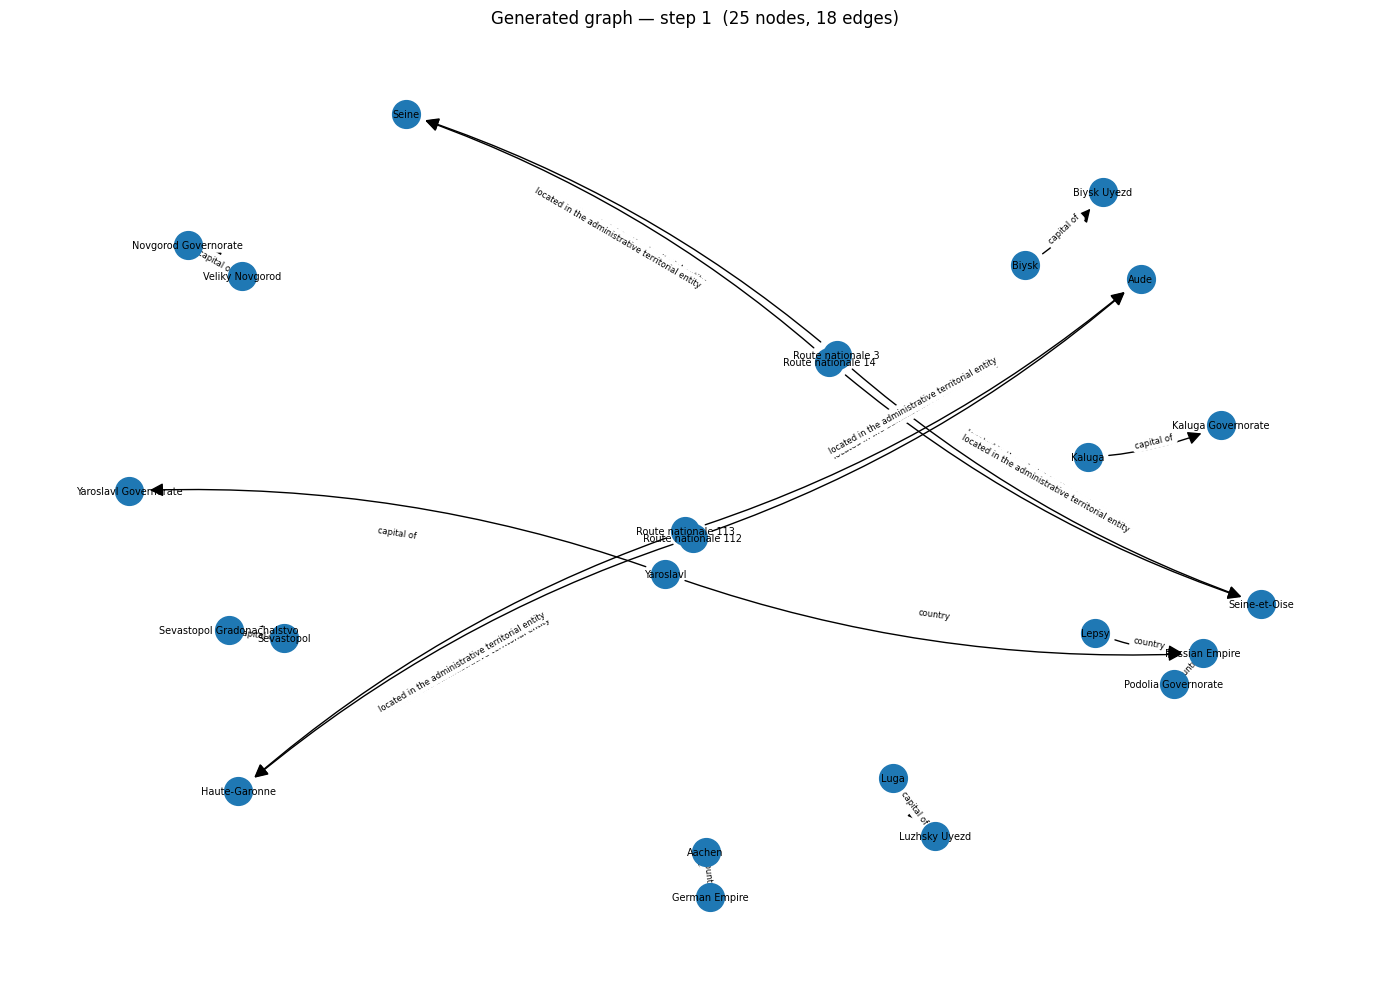

step 1: 25 nodes, 18 edges


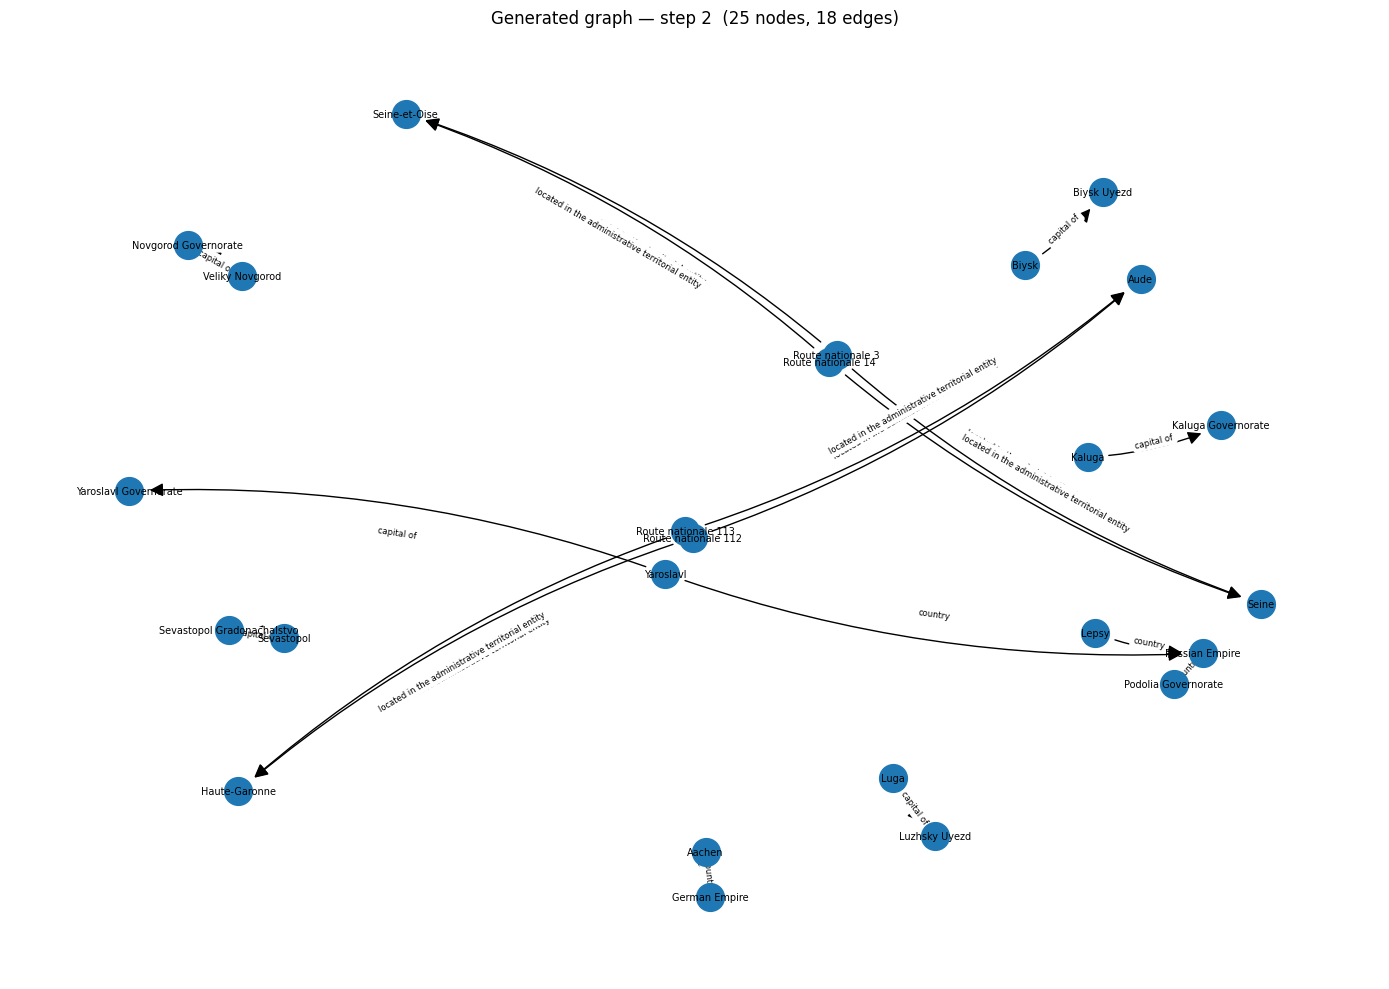

step 2: 25 nodes, 18 edges


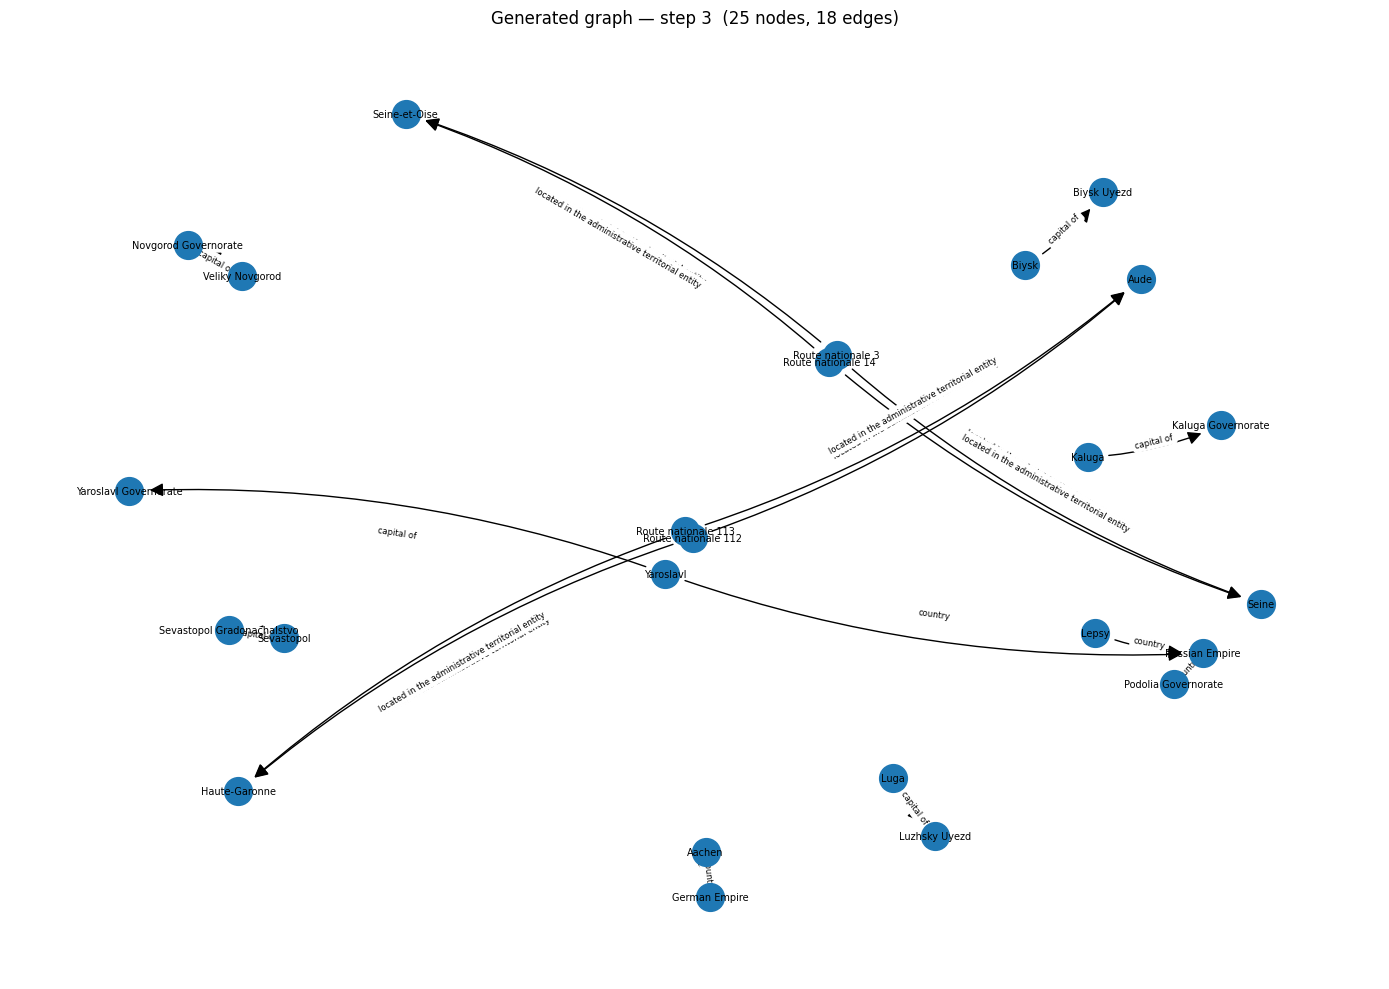

step 3: 25 nodes, 18 edges


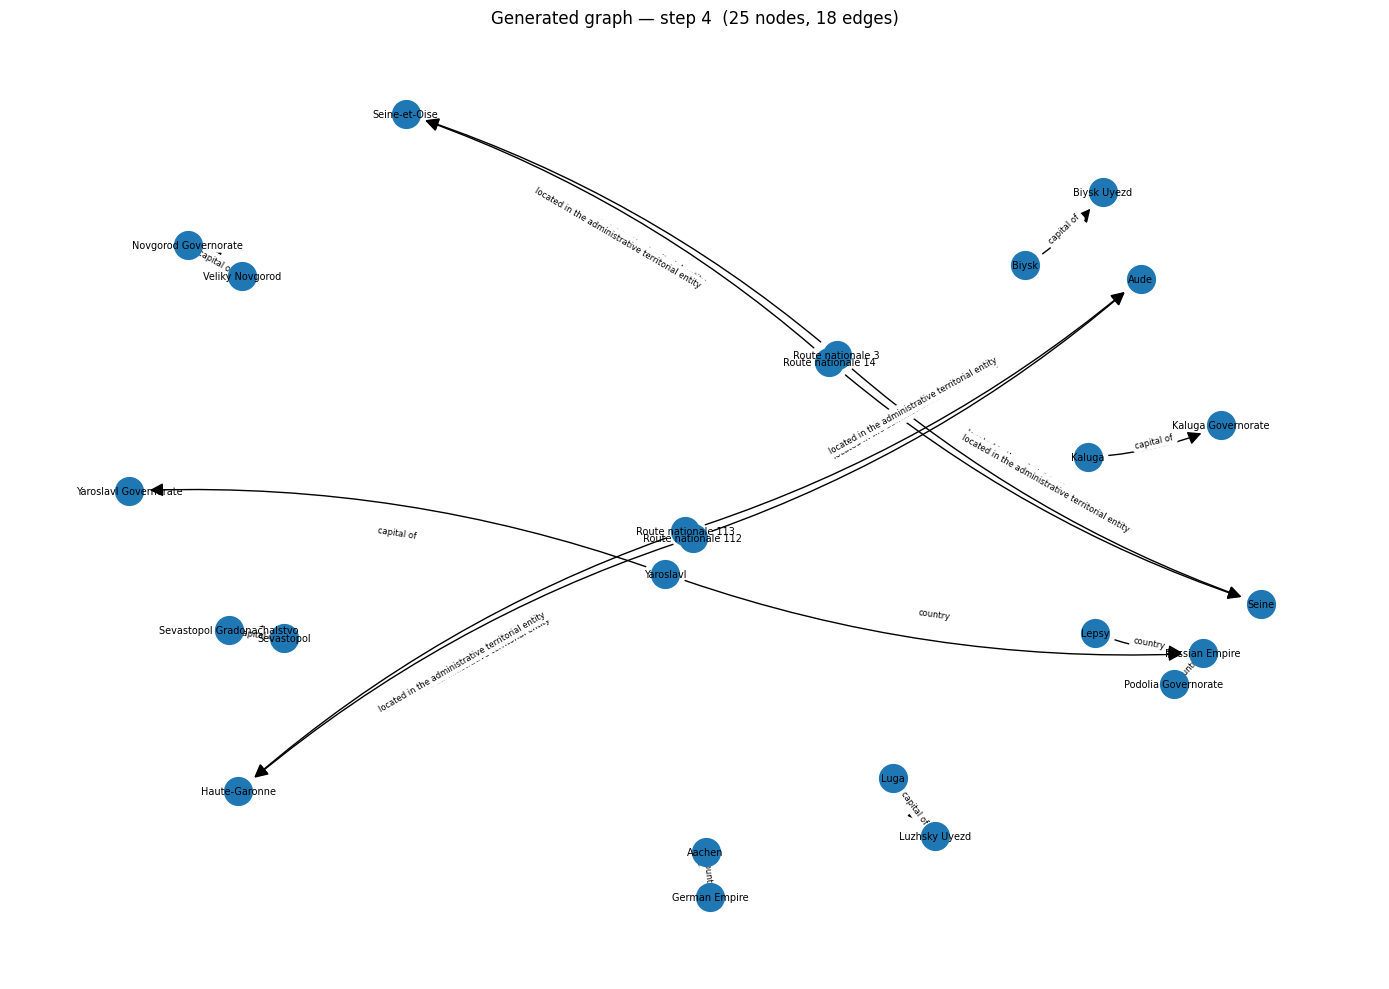

step 4: 25 nodes, 18 edges


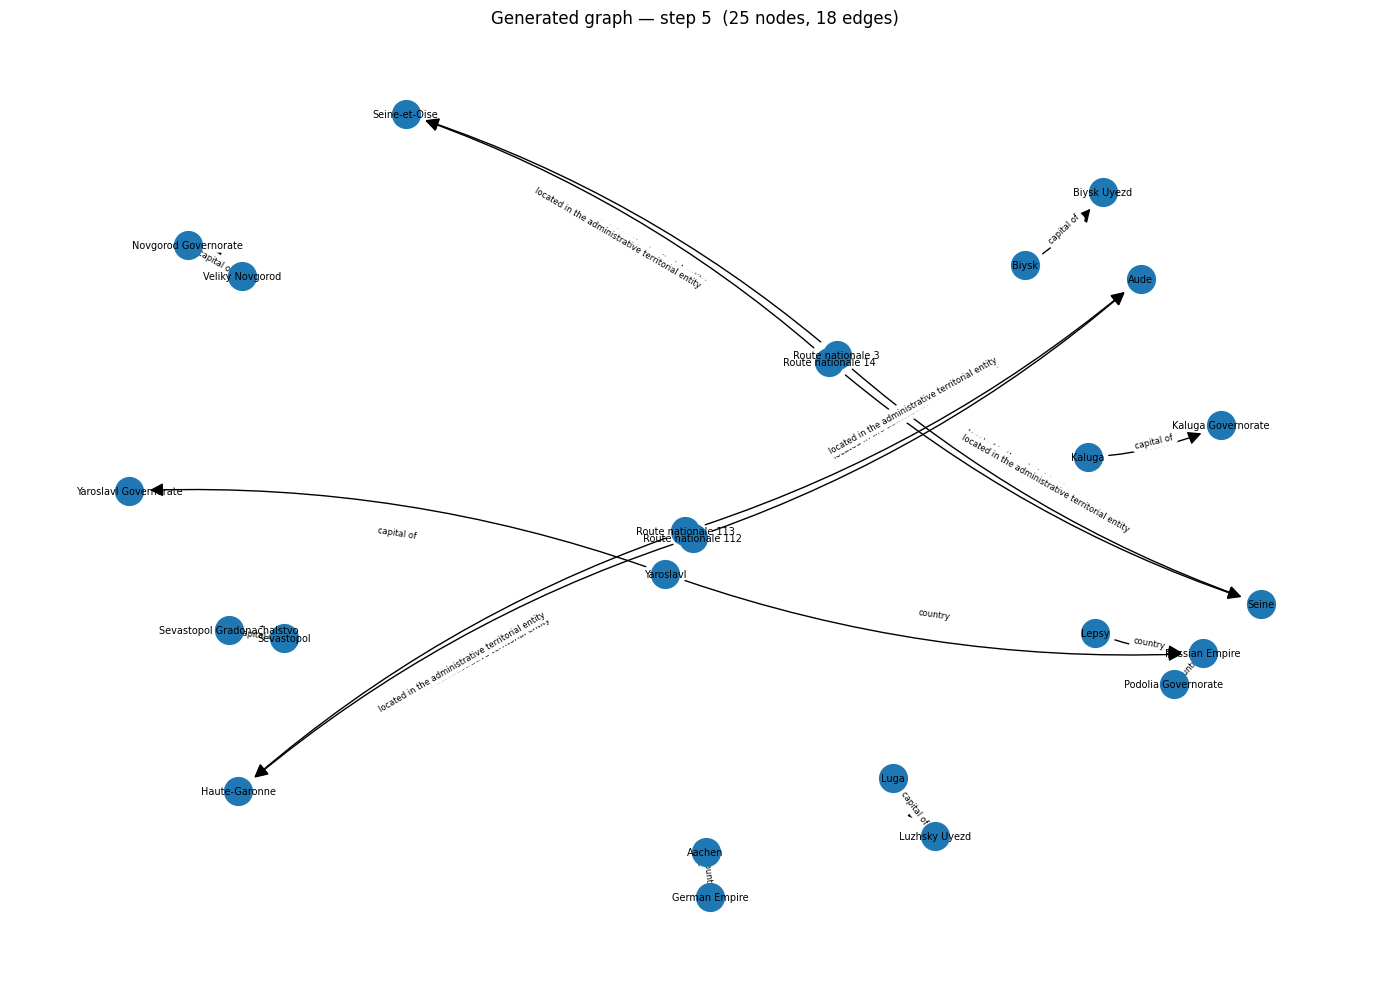

step 5: 25 nodes, 18 edges


(tensor([[ 4292,  4292,  3039,  3039,  8000,  8000, 10579, 10579,  7394,  2077,
           5427, 10133,   381,  3586,  5427,  7394,  2077,  1074, 10133,  5427,
            381,  1952,  3586,  3906,  1074],
         [ 3924,  5959,  3924,  5959,  6369,  2514,  6369,  2514,   711,  7785,
           2310,   260,  1573,  2542,   260,   711,  7785,  7564,   260,  2310,
           1573,   260,  2542,  5527,  7564]], device='cuda:0'),
 tensor([13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14,  9,  9, 13,
         14,  9,  9, 14,  9, 14,  9], device='cuda:0'))

In [37]:
def sample_subgraph(edge_index, edge_type, num_nodes):
    """Keep only edges where both endpoints are among the top num_nodes by degree."""
    all_nodes, counts = edge_index.flatten().unique(return_counts=True)
    if all_nodes.numel() <= num_nodes:
        return edge_index, edge_type
    _, top_idx = torch.topk(counts.float(), num_nodes)
    keep_nodes = set(all_nodes[top_idx].tolist())
    mask = torch.tensor(
        [(s.item() in keep_nodes and d.item() in keep_nodes)
         for s, d in zip(edge_index[0], edge_index[1])],
        dtype=torch.bool,
    )
    return edge_index[:, mask], edge_type[mask]


SUBGRAPH_NODES = 50
start = dataset[100]

sub_edge_index, sub_edge_type = sample_subgraph(
    start.edge_index, start.edge_type, num_nodes=SUBGRAPH_NODES
)
print(f"subgraph: {sub_edge_index.unique().numel()} nodes, {sub_edge_index.size(1)} edges")

# --- display initial subgraph ---
G_init = nx.DiGraph()
for src_id, rel_id, dst_id in zip(sub_edge_index[0].tolist(), sub_edge_type.tolist(), sub_edge_index[1].tolist()):
    src_lbl = dataset.id_to_entity.get(src_id, str(src_id))
    dst_lbl = dataset.id_to_entity.get(dst_id, str(dst_id))
    rel_lbl = dataset.id_to_rel.get(rel_id, str(rel_id))
    G_init.add_edge(src_lbl, dst_lbl, relation=rel_lbl)

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G_init, seed=42)
nx.draw_networkx_nodes(G_init, pos, node_size=400, ax=ax)
nx.draw_networkx_labels(G_init, pos, font_size=7, ax=ax)
nx.draw_networkx_edges(
    G_init, pos, ax=ax,
    arrows=True, arrowstyle='-|>', arrowsize=20,
    connectionstyle='arc3,rad=0.1',
    min_source_margin=15, min_target_margin=15,
)
nx.draw_networkx_edge_labels(
    G_init, pos,
    edge_labels=nx.get_edge_attributes(G_init, 'relation'),
    font_size=6, ax=ax,
)
ax.set_title(
    f"Initial subgraph (t=100) — "
    f"{G_init.number_of_nodes()} nodes, {G_init.number_of_edges()} edges"
)
ax.axis('off')
plt.tight_layout()
plt.show()

model.gen(
    x_global     = dataset.x_global,
    edge_index   = sub_edge_index,
    edge_type    = sub_edge_type,
    id_to_entity = dataset.id_to_entity,
    id_to_rel    = dataset.id_to_rel,
    num_steps    = 5,
    topk         = 25,
    threshold    = 0.5,
    device       = device,
)


In [36]:
# import os
# from datetime import datetime

# save_dir = "models"
# os.makedirs(save_dir, exist_ok=True)

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# save_path = os.path.join(save_dir, f"temporal_gnn_{timestamp}.pt")

# torch.save(model, save_path)
# print(f"saved full model to {save_path}")